# Лабораторная работа №1
## *Предобработка текста*
по курсу Обработка естественного языка  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Коротеева Олеся Владимировна
**выполнили:** Иванова Мария Кирилловна
**группа:** М4121

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
import nltk.corpus
import nltk.tokenize
import re
from pymystem3 import Mystem
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay


### 1) Загрузка и объединение данных

In [2]:
negative_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\negative.csv'
positive_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\positive.csv'

In [5]:
#считываем файл
negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)

In [6]:
sentiment = pd.concat([negative_df, positive_df])[['id','ttext', 'ttype']]

In [7]:
sentiment.loc[(sentiment.ttype < 0), ('ttype')] = 0
sentiment

,id,ttext,ttype
0,408906762813579264,на работе был полный пиддес :| и так каждое за...,0
1,408906818262687744,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,408906858515398656,@elina_4post как говорят обещаного три года жд...,0
3,408906914437685248,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,408906914723295232,"Обновил за каким-то лешим surf, теперь не рабо...",0
...,...,...,...
9995,409208735219736576,"Все равно, я бы чувствовала себя лучше, если б...",1
9996,409208736738476032,-Я пошла вешаться...-Что?! Что случилось?-Проб...,1
9997,409208736885248000,"Идеальный перерыв с любимой Катюхой, пиано мас...",1
9998,409208737015283712,Удахгүй дүн гарахаар мэдээлэл хийнээ :)) http:...,1


### 2) Удаление стоп-слов

In [8]:
nltk.download('stopwords')
russian_stopwords = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Landi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
words_to_exclude = {'лучше', 'хорошо'}
final_stopwords = russian_stopwords - words_to_exclude


In [10]:
# Функция для удаления стоп-слов
def remove_stopwords(text):
    words = str(text).lower().split()
    words = [w for w in words if w not in final_stopwords]
    return ' '.join(words)

In [11]:
sentiment['ttext'] = sentiment['ttext'].apply(remove_stopwords)

In [12]:
sentiment

,id,ttext,ttype
0,408906762813579264,работе полный пиддес :| каждое закрытие месяца...,0
1,408906818262687744,"коллеги сидят рубятся urban terror, из-за долб...",0
2,408906858515398656,@elina_4post говорят обещаного года ждут...((,0
3,408906914437685248,"желаю хорошего полёта удачной посадки,я буду о...",0
4,408906914723295232,"обновил каким-то лешим surf, работает простопл...",0
...,...,...,...
9995,409208735219736576,"равно, чувствовала лучше, женщина-детектив. *:...",1
9996,409208736738476032,-я пошла вешаться...-что?! случилось?-проблемы...,1
9997,409208736885248000,"идеальный перерыв любимой катюхой, пиано масте...",1
9998,409208737015283712,удахгүй дүн гарахаар мэдээлэл хийнээ :)) http:...,1


### 3) Извлечение лингвистических признаков

In [13]:
mystem = Mystem()

In [ ]:
def preprocess_text(text):
    text = str(text).lower()
    lemmas = mystem.lemmatize(text)
    
    # Убираем пустые строки, пунктуацию и служебные символы
    lemmas = [t for t in lemmas if t.strip() and re.match(r'^[a-zа-яё]+$', t)]    
    return lemmas

In [15]:
sentiment['ttext'] = sentiment['ttext'].apply(preprocess_text)

In [16]:
sentiment.to_csv('sentiment_processed.csv', index=False, encoding='utf-8')

Словарь

In [22]:
dictionary_path = 'C:\\Users\\Landi\ИТМО\\2 сем\\NLP\\lab1\\words_all_full_rating.csv'

In [29]:
dictionary_df = pd.read_csv(dictionary_path, delimiter=';', encoding='windows-1251')

In [31]:
dictionary_df.head(10)

,Words,mean,dispersion,average rate,Unnamed: 4
0,аборигенный,"-0,25","0,433012701892219",0,NaN
1,аборт,-1,"0,816496580927726",-1,NaN
2,абрамович,0,0,0,NaN
3,абсолютный,"0,333333333333333","0,471404520791032",0,NaN
4,абстрактный,"-0,111111111111111","0,87488976377909",0,NaN
5,абсурд,-1,0,-1,NaN
6,абсурдно,-1,0,-1,NaN
7,абсурдный,-1,0,-1,NaN
8,абхаз,0,0,0,NaN
9,абхазия,0,0,0,NaN


In [ ]:
sentiment_dict = dict(zip(dictionary_df['Words'], dictionary_df['average rate']))

def extract_features(text_lemmas):
    scores = []
    for word in text_lemmas:
        if word in sentiment_dict:
            scores.append(float(sentiment_dict[word]))
    
    if not scores:
        scores = [0]
    
    # признаки
    mean_val = np.mean(scores)
    max_val = np.max(scores)
    min_val = np.min(scores)
    sum_val = np.sum(scores)
    pos_count = sum(1 for s in scores if s > 0)
    neg_count = sum(1 for s in scores if s < 0)
    
    return [mean_val, max_val, min_val, sum_val, pos_count, neg_count]

In [34]:
# Применяем функцию ко всем текстам
features = sentiment['ttext'].apply(extract_features)

In [ ]:
# DataFrame с признаками
features_df = pd.DataFrame({
    'id': sentiment['id'].values,
    'mean': [f[0] for f in features],
    'max': [f[1] for f in features],
    'min': [f[2] for f in features],
    'sum': [f[3] for f in features],
    'pos_count': [f[4] for f in features],
    'neg_count': [f[5] for f in features],
    'ttype': sentiment['ttype'].values
})

In [38]:
features_df

,id,mean,max,min,sum,pos_count,neg_count,ttype
0,408906762813579264,0.000000,0.0,0.0,0.0,0,0,0
1,408906818262687744,0.000000,0.0,0.0,0.0,0,0,0
2,408906858515398656,0.000000,0.0,0.0,0.0,0,0,0
3,408906914437685248,0.666667,1.0,0.0,2.0,2,0,0
4,408906914723295232,0.000000,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...
19995,409208735219736576,0.000000,0.0,0.0,0.0,0,0,1
19996,409208736738476032,-0.500000,0.0,-1.0,-1.0,0,1,1
19997,409208736885248000,1.000000,1.0,1.0,2.0,2,0,1
19998,409208737015283712,0.000000,0.0,0.0,0.0,0,0,1


In [39]:
features_df.to_csv('p3_sentiment_features.csv', index=False)

### Построение классификатра

In [46]:
sentiment.head()

,id,ttext,ttype
0,408906762813579264,"[работа, полный, пиддеса, каждый, закрытие, ме...",0
1,408906818262687744,"[коллега, сидеть, рубиться, из-за, долбать, ви...",0
2,408906858515398656,"[говорить, обещаной, год, ждать]",0
3,408906914437685248,"[желать, хороший, полет, удачный, посадка, я, ...",0
4,408906914723295232,"[обновлять, какой-то, леший, работать, простоп...",0


In [43]:
#разделяем датасет на train и test
X=sentiment['ttext'].values.tolist()
y=sentiment['ttype'].values.tolist()

In [49]:
X = features_df.drop(['id','ttype'], axis=1)
y=sentiment['ttype'].values.tolist()

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [62]:
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
def plot_confusion(model_name, y_pred, y_test):
   
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    
    # Подписи классов
    labels = ["Отрицательный", "Положительный"]
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel("Предсказанные метки")
    plt.ylabel("Истинные метки")
    plt.title(f"Матрица ошибок ({model_name})")
    plt.show()

In [66]:
# Создание и обучение модели
svc = SVC(random_state=42, kernel='rbf')
svc.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False



Classification report:

               precision    recall  f1-score   support

           0       0.54      0.89      0.67      2990
           1       0.69      0.25      0.36      3010

    accuracy                           0.57      6000
   macro avg       0.61      0.57      0.52      6000
weighted avg       0.61      0.57      0.52      6000



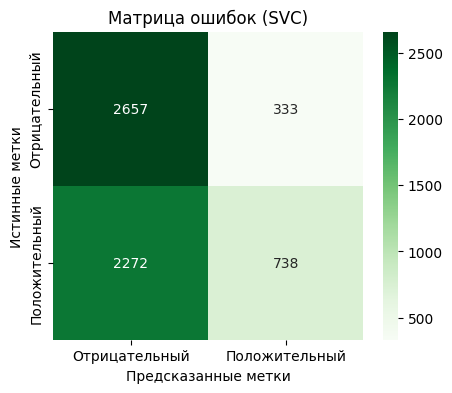

In [67]:
# Предсказания
y_pred_svc = svc.predict(X_test_scaled)

# Метрики

acc = accuracy_score(y_test, y_pred_svc)

print("\nClassification report:\n\n", classification_report(y_test, y_pred_svc))
plot_confusion("SVC", y_pred_svc, y_test)